<a href="https://colab.research.google.com/github/ujwaljain506-hash/anime-recommender/blob/main/day4_eda_insights.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [16]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [17]:
import pandas as pd
df = pd.read_csv('/content/drive/MyDrive/anime-dataset-2023.csv')
print("File Loaded")

File Loaded


In [18]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer()
tfidf_matrix = tfidf.fit_transform(df['Genres'])

print(tfidf_matrix.shape)

(24905, 28)


In [19]:
print(tfidf.get_feature_names_out())

['action' 'adventure' 'avant' 'award' 'boys' 'comedy' 'drama' 'ecchi'
 'erotica' 'fantasy' 'fi' 'garde' 'girls' 'gourmet' 'hentai' 'horror'
 'life' 'love' 'mystery' 'of' 'romance' 'sci' 'slice' 'sports'
 'supernatural' 'suspense' 'unknown' 'winning']


In [20]:
df['Genres'] = df['Genres'].str.replace(' ,', ',').str.replace(', ',',').str.replace(' ', '_').str.replace('-', '_')

In [21]:
tfidf = TfidfVectorizer()
tfidf_matrix = tfidf.fit_transform(df['Genres'])
print(tfidf.get_feature_names_out())

['action' 'adventure' 'avant_garde' 'award_winning' 'boys_love' 'comedy'
 'drama' 'ecchi' 'erotica' 'fantasy' 'girls_love' 'gourmet' 'hentai'
 'horror' 'mystery' 'romance' 'sci_fi' 'slice_of_life' 'sports'
 'supernatural' 'suspense' 'unknown']


In [22]:
df = df[df['Genres'] != 'unknown']
print(df.shape)

(24905, 24)


In [23]:
df = df[~df['Genres'].str.contains('UNKNOWN')]
print(df.shape)

(19976, 24)


In [24]:
tfidf = TfidfVectorizer()
tfidf_matrix = tfidf.fit_transform(df['Genres'])
print(tfidf_matrix.shape)

(19976, 21)


Concept: Cosine Similarity
Remember our TF-IDF matrix — each anime is represented as a list of 22 numbers (one per genre). For example:

Cowboy Bebop → [0.6, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0.8, 0, 0, 0, 0, 0]

Trigun → [0.5, 0.7, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0.6, 0, 0, 0, 0, 0]

Cosine similarity measures the angle between two such lists. If two anime point in the same direction (similar genres), the angle is small → similarity score close to 1. If they're completely different, angle is large → similarity score close to 0.

In [25]:
from sklearn.metrics.pairwise import cosine_similarity

cosine_sim = cosine_similarity(tfidf_matrix, tfidf_matrix)
print(cosine_sim.shape)

(19976, 19976)


In [26]:
print(cosine_sim[0])

[1.         0.5708853  0.46690143 ... 0.         0.21070862 0.41672338]


In [41]:
def recommend_anime(title):
    # Find the index of the anime in the dataframe
    match = df[(df['Name'] == title) | (df['English name'] == title)]

    if match.empty:
        return "Anime not found! Check the spelling."

    idx = match.index[0]
    # Get similarity scores for this anime against all others
    sim_scores = list(enumerate(cosine_sim[idx]))

    # Sort by similarity score, highest first
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)

    # Skip the first result (the anime itself), take next 10
    sim_scores = sim_scores[1:11]

    # Get the anime indices
    anime_indices = [i[0] for i in sim_scores]

    # Return the anime names
    return df['Name'].iloc[anime_indices].values

print(recommend_anime('Demon Slayer: Kimetsu no Yaiba'))

['Peace Maker Kurogane' 'Air Master' 'Abashiri Ikka'
 'Sexy Commando Gaiden: Sugoi yo!! Masaru-san' 'Gunsmith Cats'
 'Kakutou Bijin Wulong: Rebirth'
 'Shinshaku Sengoku Eiyuu Densetsu: Sanada Juu Yuushi The Animation'
 'Battle Spirits: Ryuuko no Ken' 'Nekojiru Gekijou Jirujiru Original'
 'Taiho Shichau zo (TV)']


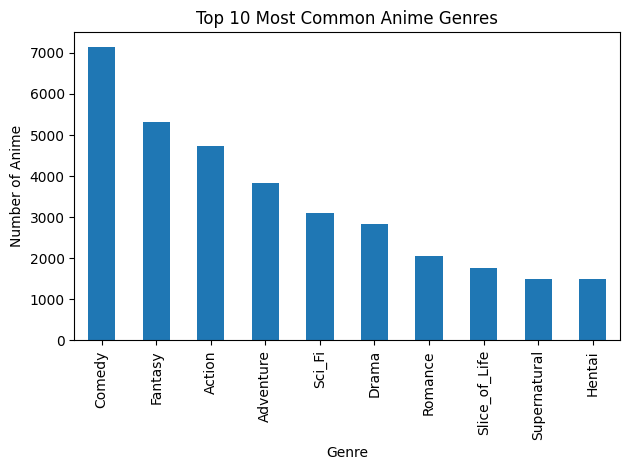

In [28]:
import matplotlib.pyplot as plt

genre_counts = df['Genres'].str.split(',').explode().str.strip().value_counts().head(10)
genre_counts.plot(kind='bar')
plt.title('Top 10 Most Common Anime Genres')
plt.xlabel('Genre')
plt.ylabel('Number of Anime')
plt.tight_layout()
plt.show()

In [34]:
df['Score'] = pd.to_numeric(df['Score'], errors='coerce')
print(df['Score'].dtype)

float64


In [35]:
df['Score'].dtype

dtype('float64')

In [33]:
df['Score'].value_counts().head(10)

,count
Score,
UNKNOWN,6037
6.31,73
6.54,73
6.51,73
6.52,71
6.36,70
6.73,70
6.25,69
7.03,69


In [32]:
df['Score'].value_counts().tail(10)

,count
Score,
3.26,1
4.09,1
8.79,1
3.1,1
4.05,1
2.63,1
8.6,1
2.9,1
3.65,1


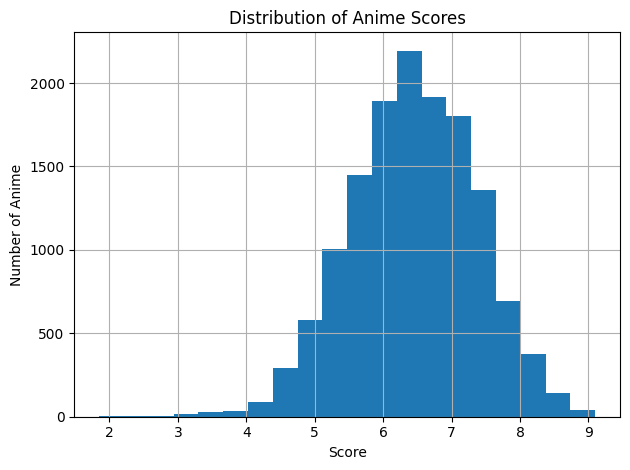

In [36]:
df['Score'].hist(bins=20)
plt.title('Distribution of Anime Scores')
plt.xlabel('Score')
plt.ylabel('Number of Anime')
plt.tight_layout()
plt.show()

In [40]:
def recommend_anime(title):
    match = df[(df['Name'] == title) | (df['English name'] == title)]

    if match.empty:
        return "Anime not found! Check the spelling."

    idx = match.index[0]
    sim_scores = list(enumerate(cosine_sim[idx]))
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)
    sim_scores = sim_scores[1:11]
    anime_indices = [i[0] for i in sim_scores]

    results = df[['Name', 'Score']].iloc[anime_indices].reset_index(drop=True)
    results.index += 1
    return results

recommend_anime('Demon Slayer: Kimetsu no Yaiba')

,Name,Score
1,Peace Maker Kurogane,7.30
2,Air Master,6.97
3,Abashiri Ikka,5.28
4,Sexy Commando Gaiden: Sugoi yo!! Masaru-san,7.63
5,Gunsmith Cats,7.35
6,Kakutou Bijin Wulong: Rebirth,6.82
7,Shinshaku Sengoku Eiyuu Densetsu: Sanada Juu Y...,5.90
8,Battle Spirits: Ryuuko no Ken,4.78
9,Nekojiru Gekijou Jirujiru Original,6.43
10,Taiho Shichau zo (TV),7.54
